<a href="https://colab.research.google.com/github/srinath070909/python_list/blob/main/13_03_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install pillow pytesseract


In [7]:
!apt-get update
!apt-get install tesseract-ocr


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [69.0 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,374 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,738 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu

In [8]:
from PIL import Image  # Import Image from PIL
import pytesseract  # Import pytesseract for OCR

# Open the image file
image_path = "invoice.jpg"  # Path to your image file
image = Image.open(image_path)

# Use Tesseract OCR to extract text from the image
text = pytesseract.image_to_string(image)

# Print the extracted text
print(text)

# Optionally, use a regex to search for the price in the text
import re

# Example regex to find a price (assuming a currency format like "$123.45")
price = re.search(r'\$\d+(\.\d{2})?', text)
if price:
    print(f"Extracted price: {price.group()}")
else:
    print("No price found.")


 

InvoiceNo: 000 00000,
DATE: 13 august 2021

en

LoReM PSUM DOOR IT AMET

LoReMipsun D010 sit AMET

{oReM PSUM B0108 SIT AMET

PAYMENT INFO:

‘TERMS AND CONDITIONS
Sa et ot cer

 

‘Thank youor you business

  

INVOICE

 

invoice To
LOREM sum

ICE Eu TOTAL
i000 1 ‘si000
stoo0 1 ssigoo
1000 1 ‘i000
sio00 1 sigoo
sioo0 1 ‘i000
‘SuBTOTAL $100.00

™xX 10%

GRANDTOTAL $100.00

  
 
  

Ramored Sign

Extracted price: $100.00


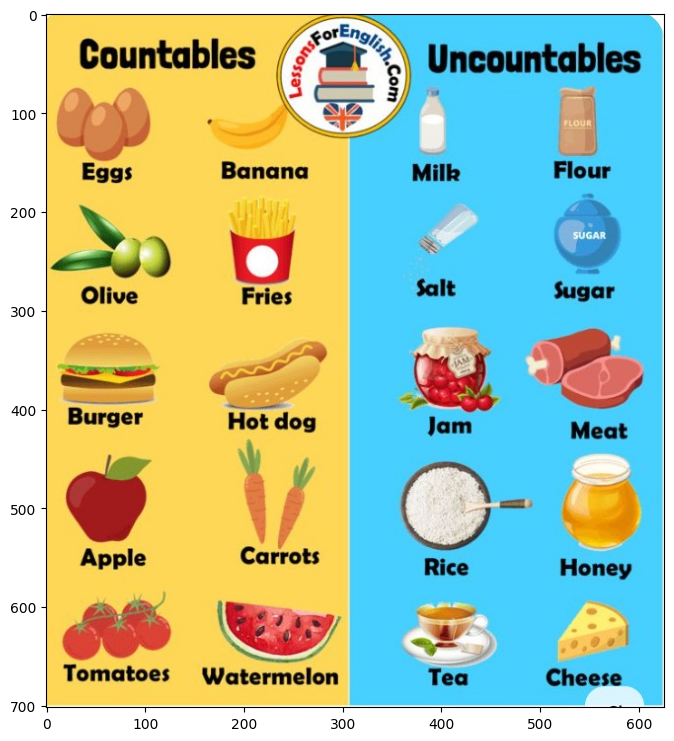

In [13]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow_hub as hub

# Load the object detection model from TensorFlow Hub
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

# Load the image
image_path = "items.jpg"  # Path to your image file
image = Image.open(image_path)
image_np = np.array(image)

# Convert image to a tensor and expand dimensions
input_tensor = tf.convert_to_tensor(image_np)
input_tensor = input_tensor[tf.newaxis,...]

# Run the model
output = model(input_tensor)

# Extract the boxes, class labels, and scores
boxes = output["detection_boxes"][0].numpy()
class_ids = output["detection_classes"][0].numpy().astype(np.int32)
scores = output["detection_scores"][0].numpy()

# Define the labels (based on COCO dataset)
labels = [
    "background", "person", "bicycle", "car", "motorcycle", "airplane", "bus",
    "train", "truck", "boat", "traffic light", "fire hydrant", "N/A", "stop sign",
    "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow", "elephant",
    "bear", "zebra", "giraffe", "N/A", "backpack", "umbrella", "N/A", "handbag",
    "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
    "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "N/A", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
    "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant", "bed", "N/A",
    "dining table", "toilet", "N/A", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

# Count the detected objects
object_counts = {}
for i, class_id in enumerate(class_ids):
    if scores[i] > 0.5:  # Threshold for confidence
        label = labels[class_id]
        object_counts[label] = object_counts.get(label, 0) + 1

# Print the results
for obj, count in object_counts.items():
    print(f"{obj}: {count}")

# Visualize the detections
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)

# Draw bounding boxes
for i, box in enumerate(boxes):
    if scores[i] > 0.5:  # Threshold for confidence
        ymin, xmin, ymax, xmax = box
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color='red', linewidth=3))

plt.show()


In [14]:
pip install youtube-transcript-api pytube


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.9 MB/s eta 0:00:00


In [16]:
from youtube_transcript_api import YouTubeTranscriptApi

def get_youtube_transcript(video_url):
    """Fetches the transcript of a YouTube video."""
    video_id = video_url.split("v=")[1].split("&")[0]  # Extract video ID
    transcript = YouTubeTranscriptApi.get_transcript(video_id)
    full_text = " ".join([t["text"] for t in transcript])
    return full_text

# Example Usage
video_url = "https://www.youtube.com/watch?v=unYDoA8QGH0&list=PLWEpztHwA4ZT2QlHC74oIz4MsawcvE-QX"
video_transcript = get_youtube_transcript(video_url)
print("Transcript:\n", video_transcript[:500])  # Show first 500 characters


Transcript:
 hi guys today I'm going to introduce you what is machine learning uh these are my presentation content what is machine learning what are the different applications of machine learning different types of machine learning and how to build a machine learning system or model then various kinds of algorithms and later on in this series we are going to take a Hands-On you know case studies or doing programming for various kinds of up algorithms so what is machine learning so machine learning is nothin


In [18]:
# Configure Gemini API
import google.generativeai as genai
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)


In [30]:
import google.auth
from google.auth.transport.requests import Request
import requests

# Define the API key for Gemini (make sure you have the correct API key)
API_KEY = "your-valid-gemini-api-key"

# Define the endpoint
url = "https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent"

# Define the request headers with the API key
headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
}

# Prepare the body of the request with the video transcript text
data = {
    "prompt": f"Extract the key takeaways and insights from the following YouTube video transcript:\n\n{video_transcript}",
    "temperature": 0.7,  # Adjust creativity level
    "max_tokens": 150,  # Adjust length of insights
}

# Make the POST request
response = requests.post(url, headers=headers, json=data)

# Check if the request was successful
if response.status_code == 200:
    insights = response.json()['text']  # Assuming the response contains the text field
    print("Key Insights:\n", insights)
else:
    print(f"Failed to get insights: {response.status_code}, {response.text}")


Failed to get insights: 401, {
  "error": {
    "code": 401,
    "message": "Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.",
    "status": "UNAUTHENTICATED"
  }
}



In [32]:
import requests
import json

# Define your API key for Gemini (ensure it's the correct key)
API_KEY = "your-valid-gemini-api-key"  # Replace with your actual API key

# Define the endpoint for Gemini API
url = "https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent"

# Set the headers with the authorization token (Gemini's Bearer token)
headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
}

# Prepare the body of the request with the video transcript text
data = {
    "prompt": f"Analyze the sentiment of the following YouTube video transcript. Is it positive, negative, or neutral?\n\n{video_transcript}",
    "temperature": 0.7,  # Adjust creativity level if needed
    "max_tokens": 100,  # Adjust token length based on expected response
}

# Make the POST request
response = requests.post(url, headers=headers, json=data)

# Check if the request was successful
if response.status_code == 200:
    sentiment = response.json()['text']  # Assuming the response contains the sentiment result
    print("Sentiment Analysis:\n", sentiment)
else:
    print(f"Failed to get sentiment: {response.status_code}, {response.text}")


Failed to get sentiment: 401, {
  "error": {
    "code": 401,
    "message": "Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.",
    "status": "UNAUTHENTICATED"
  }
}

